In [48]:
import numpy as np
import torch
import scanpy as sc
import anndata as ad
import os
import pandas as pd
from utils.preprocess import *

In [2]:
import os
os.environ["PYKEOPS_VERBOSE"] = "0"
import sys
sys.path.append(os.path.abspath("conditional-flow-matching"))
    
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import torch
import torchsde
from torchdyn.core import NeuralODE
from tqdm import tqdm

from torchcfm.conditional_flow_matching import *
from torchcfm.models import MLP
from visualize.plots import *

In [3]:
import random
import umap
from models.modules import *
from visualize.plots import *

In [4]:
import matplotlib.pyplot as plt
%matplotlib inline
# %matplotlib widget

In [5]:
from scripts.run_model import *
from eval.eval import *

In [6]:
%reload_ext autoreload
%autoreload 2

In [7]:
############################################################

In [8]:
torch.manual_seed(42)
np.random.seed(42)

In [9]:
energy_only = False
normalize = True
reload = False
d = 5
t = 4

In [10]:
config = Config(
    {        
        "model_class": "metricflow",
        "score_max_epochs": 500,
        "energy_max_epochs": 2000,
        "metric_max_epochs": 2,
        "embed_max_epochs": 2 if energy_only else 5000,
        "flow_max_epochs": 2 if energy_only else 5000,
        
        "lr": 1e-4,
        "dropout": 0.0,
        "pc_dim": d,
        "cond_dim": d,
        "hidden_dim": 512,
        "score_batch_size": 4096,
        "flow_batch_size": 256,
        "num_freq": 32,
        "num_layers": 4,
        "control_only": True,
        "force_cpu": False,
        "constrain": False,
        "gradient_clip_val": 10.0,
        "loader_batch_size": 20,
        "accumulate_grad_batches": 1,
        "warmup_steps": 0,
        "ema_decay": .999,

        "mfm_benchmark": False,

        "pita_steps": 2,

        "score_alpha": 1.0,

        "energy_noise_sigma": 0.0,
        "metric_scale": 10,
        "metric_sigma": 0.05,

        "ot_in_embed": True,
        "fast_ot": False,

        "num_sigmas": 20,
        "sigma_min": 0.01,
        "sigma_max": 0.5,

        "sigma_dim": 32,

        "score_beta_min": 1.0,
        "score_beta_max": 1.0,
        
        "latent_dim": 100,

        "skip": True,
        "rescale": 0.5,

        "pre_low_q": .05,
        "pre_high_q": .98,
        "low_q": .05,
        "high_q": .95,

        "weight_beta": 0.3,

        "gamma": 0.2,

        "sigma": 0.1,

        "n_neighbors": 10,
        "resolution": 0.2,
    }
)

In [11]:
### Straight BENCHMARK ###
config.score_max_epochs = 2
config.energy_max_epochs = 2
config.metric_max_epochs = 2
config.embed_max_epochs = 2
config.flow_max_epochs = 4000
config.pita_steps = 1
config.rescale = 0.0
config.sigma = 0.2
normalize = True

In [12]:
# ### MFM BENCHMARK ###
# config.score_max_epochs = 2
# config.energy_max_epochs = 2
# config.metric_max_epochs = 1000
# config.mfm_benchmark = True
# config.K = 500
# config.kappa = 1.0
# config.pita_steps = 1

In [13]:
if reload:
    config.score_max_epochs = 2
    config.energy_max_epochs = 2
    config.metric_max_epochs = 2
    config.embed_max_epochs = 2
    config.flow_max_epochs = 2


In [14]:
project = "cite"

In [15]:
wandb.finish()

In [16]:
print(config.model_class)

metricflow


In [17]:
from collections import namedtuple
Holdout = namedtuple('Holdout', ['t', 'gene'])
holdout = Holdout(t, 'ctrl-inj')
print(holdout.gene)

ctrl-inj


In [18]:
#TODO: we leak information here
#But do earlier methods cheat?  PCA before or after removing a timepoint?

In [19]:
adata, values = process_data(pc_dim=config.pc_dim, data="cite")

In [20]:
timepoints = sorted(adata.obs['timepoint'].unique())
t_minus = timepoints[timepoints.index(holdout.t)-1]
t_plus = timepoints[timepoints.index(holdout.t)+1]

In [21]:
#NORMALIZING::::

adata.uns['std'] = np.ones((1,d))
adata_raw = adata.copy()

if normalize:
    adata.uns['std'] = np.std(adata.obsm['X_pca'], axis=0, keepdims=True)
    adata.obsm['X_pca'] /= adata.uns['std']

In [22]:
test_bool = adata.obs['timepoint'] == holdout.t
train_bool = adata.obs['timepoint'].isin([t_minus, t_plus])
adata_train = adata[train_bool]
adata_test = adata[test_bool]

In [23]:
conditions, dataset = extract_dataset(adata_train, values)

In [24]:
# sc.pp.neighbors(adata_train, n_neighbors=config.n_neighbors)
# sc.tl.leiden(adata_train, resolution=config.resolution)
# sc.tl.umap(adata_train)
# sc.pl.umap(adata_train, color=['leiden'])

In [25]:
pre_score_model, pre_energy_model, score_model, energy_model, metric_model, embed_model, flow_model = run_full_model(config, project, adata_train, values, conditions, dataset)

/home/azweig/projects/zebrafish/datasets/process.py:82: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_train, resolution=resolution)
wandb: Currently logged in as: az831 (az831-new-york-genome-center) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


Running phase score:.......


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/pytorch_lightning/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
wandb: logging graph, to disable use `wandb.watch(log_graph=False)`
You are using a CUDA device ('NVIDIA GeForce RTX 4080 SUPER') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name        | Type             | Params | Mode 
-----------------------------------------------------

score_pita


/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
`Trainer.fit` stopped: `max_epochs=2` reached.


...

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/pytorch_lightning/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
wandb: logging graph, to disable use `wandb.watch(log_graph=False)`
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type               | Params | Mode 
------------------------------------------------------------
0 | embed_net    | SimpleEmbedNet     | 846 K  | train
1 | geo_net      | SinNet             | 835 K  | train
2 | metric_model | MetricNetTrainBase | 1.1 M  | eval 
------------------------------------------------------------
1.7 M     Trainable params
1.1 M     Non-trainable params
2.8 M     Total params
11.197    Total estimated model params size (MB)
32 

epoch,▁█
train_loss,█▁
trainer/global_step,▁█
epoch,1
train_loss,60.67656
trainer/global_step,1


Running phase flow:.......


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/pytorch_lightning/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
wandb: logging graph, to disable use `wandb.watch(log_graph=False)`
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type           | Params | Mode 
-----------------------------------------------------
0 | flow_net  | SinNet         | 833 K  | train
1 | geo_net   | SinNet         | 835 K  | eval 
2 | embed_net | SimpleEmbedNet | 846 K  | eval 
-----------------------------------------------------
1.7 M     Trainable params
846 K     Non-trainable params
2.5 M     Total params
10.060    Total estimated model params size (MB)
16        Modules in train mode
32        Mod

epoch,▁▁▁▁▁▂▂▂▂▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇██
train_loss,█▅▄▃▃▃▂▂▂▃▂▂▂▁▂▂▂▂▂▂▂▂▂▂▁▁▂▂▂▂▁▂▂▁▂▃▂▂▂▂
trainer/global_step,▁▁▁▁▁▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▅▅▆▆▆▆▇▇▇████
epoch,3999
train_loss,0.19488
trainer/global_step,3999


In [26]:
# torch.save(score_model.state_dict(), 'score_model.pth')
# torch.save(energy_model.state_dict(), 'energy_model.pth')
# torch.save(metric_model.state_dict(), 'metric_model.pth')
# torch.save(embed_model.state_dict(), 'embed_model.pth')
# torch.save(flow_model.state_dict(), 'flow_model.pth')

In [27]:
if reload:
    score_model.load_state_dict(torch.load('score_model.pth'))
    energy_model.load_state_dict(torch.load('energy_model.pth'))
    metric_model.load_state_dict(torch.load('metric_model.pth'))
    embed_model.load_state_dict(torch.load('embed_model.pth'))
    flow_model.load_state_dict(torch.load('flow_model.pth'))

In [28]:
from visualize.plots import *

In [29]:
def visualize_energy(
    embed_model,
    e_model,
    samples,                       # AnnData OR torch.Tensor [N,D]
    *,
    # --- AnnData-specific options ---
    layer=None,
    use_rep=None,
    obsm_key="X_umap",
    recompute_umap=False,
    copy=False,
    # --- energy options ---
    prune=False,
    prune_attr="G_interpolate",
    invert=False,
    color_clip=None,
    # --- plotting / compute options ---
    subsample=None,
    batch_size=512,
    device=None,
    random_state=0,
    cmap="inferno",
    kde_cmap="viridis",            # NEW: colour‑map for density panel
    show=True,
    **scanpy_plot_kwargs,
):
    import numpy as np
    import torch
    import matplotlib.pyplot as plt
    from scipy.stats import gaussian_kde         # ← NEW

    try:
        import scanpy as sc
    except ImportError as e:
        raise ImportError(
            "visualize_energy requires scanpy.  `pip install scanpy`"
        ) from e

    # ------------------------------------------------------------------ #
    # helper for mini‑batch evaluation (unchanged)                       #
    # ------------------------------------------------------------------ #
    def _eval_model_in_batches(tensor_x, fn, bs):
        outs = []
        with torch.no_grad():
            for s in range(0, tensor_x.shape[0], bs):
                outs.append(fn(tensor_x[s : min(s + bs, tensor_x.shape[0])]))
        return torch.cat(outs, dim=0)

    # ------------------------------------------------------------------ #
    # Path A – AnnData (tensor path omitted for brevity)                 #
    # ------------------------------------------------------------------ #
    if hasattr(samples, "X") and not torch.is_tensor(samples):
        adata = samples.copy() if copy else samples
        # ---------- choose input matrix (unchanged) ----------
        if layer is not None and use_rep is not None:
            raise ValueError("Specify at most one of `layer` or `use_rep`.")
        if use_rep is not None:
            X_in = adata.obsm[use_rep]
        elif layer is not None:
            X_in = adata.layers[layer]
        else:
            X_in = adata.X
        X_np = X_in.toarray() if hasattr(X_in, "toarray") else np.asarray(X_in)

        # ---------- energy / metric tensor ----------
        x_tensor = torch.as_tensor(X_np, dtype=torch.get_default_dtype())
        if device is None:
            device = next(embed_model.parameters()).device
        x_tensor = x_tensor.to(device)

        if prune:
            fn = getattr(embed_model, prune_attr)
        else:
            fn = e_model.get_energy
        scalar = _eval_model_in_batches(x_tensor, fn, batch_size).flatten()
        # scalar = np.exp(-scalar)
        scalar_np = scalar.detach().cpu().numpy()

        # ---------- colour clipping ----------
        vmin = vmax = None
        if color_clip is not None:
            if isinstance(color_clip, tuple) and len(color_clip) == 3 and color_clip[0] == "q":
                vmin = float(np.percentile(scalar_np, color_clip[1]))
                vmax = float(np.percentile(scalar_np, color_clip[2]))
            elif isinstance(color_clip, (tuple, list)) and len(color_clip) == 2:
                vmin, vmax = map(float, color_clip)

        obs_key = ("metric_tensor" if prune else "energy")
        if invert:
            obs_key += "_density"
        adata.obs[obs_key] = scalar_np

        # ---------- make / reuse UMAP ----------
        if recompute_umap or obsm_key not in adata.obsm:
            sc.pp.neighbors(adata, use_rep="X_pca", random_state=random_state)
            sc.tl.umap(adata, random_state=random_state)
            if obsm_key != "X_umap":
                adata.obsm[obsm_key] = adata.obsm["X_umap"].copy()

        # ---------- KDE‑based density on UMAP (NEW) ----------
        umap_xy = adata.obsm['X_pca']           # shape (N, 2)
        print(umap_xy.shape)
        kde = gaussian_kde(umap_xy.T, bw_method='silverman')
        adata.obs["umap_density"] = kde(umap_xy.T)      # add to .obs

        # ---------- optional subsample for plotting ----------
        if subsample is not None and subsample < adata.n_obs:
            rng = np.random.default_rng(random_state)
            adata_plot = adata[rng.choice(adata.n_obs, subsample, replace=False)]
        else:
            adata_plot = adata

        # ---------- ensure correct key for plotting ----------
        if obsm_key != "X_umap":
            adata_plot.obsm["X_umap"] = adata_plot.obsm[obsm_key]
        plot_kwargs = dict(
            color=[obs_key, "umap_density"],  # three panels
            vmin=[vmin, None],
            vmax=[vmax, None],
            show=show,
            title=[
                f"UMAP coloured by {obs_key}",
                "UMAP point density (KDE)",
            ],
        )
        plot_kwargs.update(scanpy_plot_kwargs)

        sc.pl.umap(adata_plot, **plot_kwargs)

In [30]:
#fix the wandb.run.summary bug?
def remove_all_forward_hooks(model):
    for module in model.modules():
        module._forward_hooks.clear()

remove_all_forward_hooks(score_model)
remove_all_forward_hooks(energy_model)
remove_all_forward_hooks(embed_model)
remove_all_forward_hooks(flow_model)

In [31]:
# visualize_energy(
#     embed_model,
#     pre_energy_model,
#     adata,            # AnnData
#     use_rep="X_pca",
#     prune=False,
#     color_clip=("q", 5, 95),  # 1st-99th percentile clipping
#     cmap="inferno",
# )

/tmp/ipykernel_3920357/747921771.py:91: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[obs_key] = scalar_np


(14253, 5)


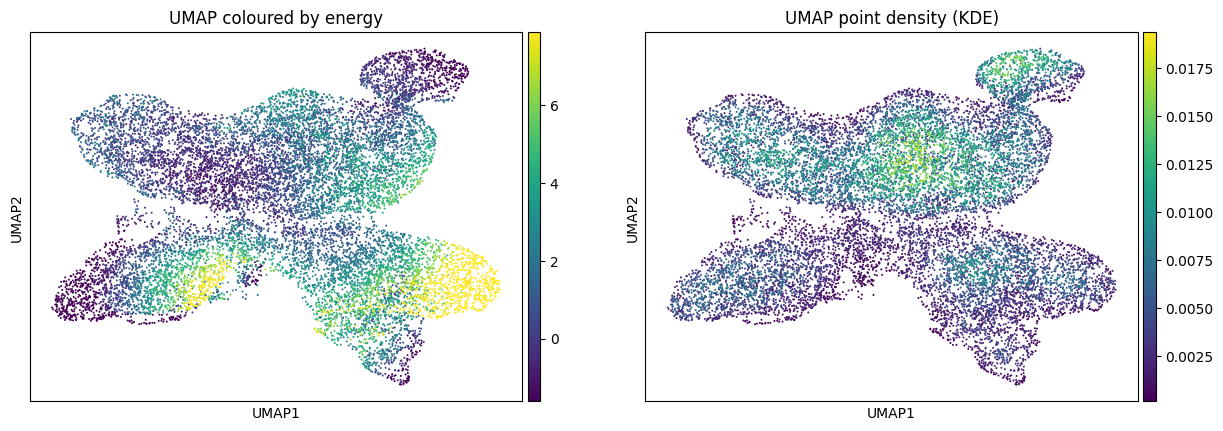

In [32]:
visualize_energy(
    embed_model,
    energy_model,
    adata_train,            # AnnData
    use_rep="X_pca",
    prune=False,
    color_clip=("q", 5, 95),  # 1st-99th percentile clipping
    cmap="inferno",
)

In [33]:
# visualize_energy(
#     embed_model,
#     energy_model,
#     adata,            # AnnData
#     use_rep="X_pca",
#     prune=True,
#     color_clip=("q", 5, 95),  # 1st-99th percentile clipping
#     cmap="inferno",
# )

In [34]:
# x = torch.from_numpy(adata_raw.obsm['X_pca'][:10]).to(embed_model.device)
# c = torch.zeros_like(x)
# t = torch.rand(x.shape[0],1).to(x.device)
# embed_model.geo_net(torch.cat([x, x], dim=-1), c, t)

In [35]:
if not energy_only:
    value = holdout.gene
    t = holdout.t
    num_traj = 6999
    
    print(predict(flow_model, adata_raw, value, conditions, num_traj, t, p=1))

13.817705154418945


### Results:

For t = 3, pca_dim = 100:

Straight geodesics: 43.33094024658203

Learned score geodesics: 42.097

Conclusion; our score is baaaaaaad, needs to be refined in a thoughtful way

### Results:

For t = 3, pca_dim = 50:

Straight geodesics: 37.80883026123047

Learned score geodesics:

### Results:

For t = 3, pca_dim = 5:

Straight geodesics reproduced: 14.787372589111328

Learned score geodesics: 14.322830200195312

for t = 4, pca_dim = 5:

straight: 13.817705154418945

learned: 

### Results:

For t = 3, pca_dim = 20:

Straight geodesics: 29.94202423095703

Learned score geodesics:

In [36]:
#VALIDATE: are the geodesics straight?

In [37]:
from torch.utils.data import TensorDataset, Sampler, DataLoader
from datasets.dataset import *

conditions, dataset = extract_dataset(adata_raw[train_bool], values)
train_dataset = ShufflingDataset(dataset, config.flow_batch_size, conditions)
train_dataloader = DataLoader(train_dataset, batch_size = config.loader_batch_size, shuffle=True)

In [38]:
for batch in train_dataloader:
    
    paths = embed_model.sample_geodesic(batch, points=1000, ot_sample=True)
    
    break

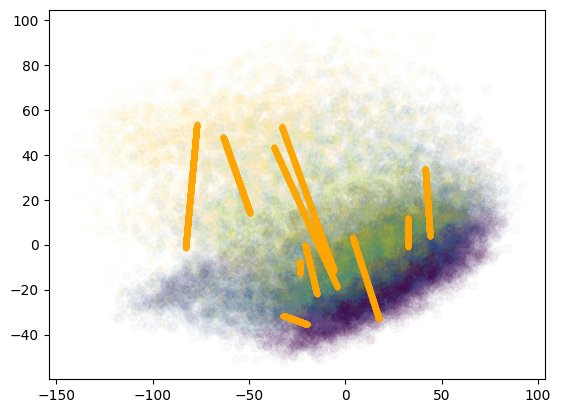

In [39]:
raw_samples = torch.from_numpy(adata_raw.obsm['X_pca']).float()
fig, ax = plt.subplots()
ax.scatter(raw_samples[:,0], raw_samples[:, 1], c=adata.obs['timepoint'], alpha=0.02)

for i in range(10):
    traj = paths[:,i]
    ax.plot(traj[:, 0], traj[:, 1], marker=".", linestyle="-", alpha=0.7, lw=1.5, color='orange')
plt.show()

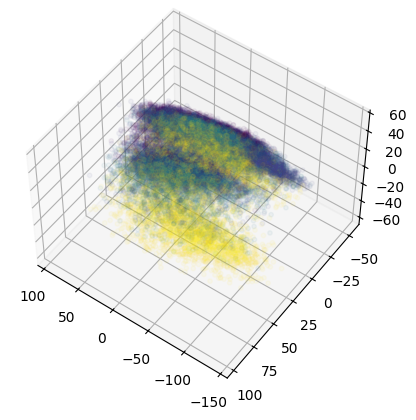

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # Needed for 3D plots

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(raw_samples[:, 0], raw_samples[:, 1], raw_samples[:, 2], c=adata.obs['timepoint'], s=10, alpha=0.05)

elev = np.random.uniform(10, 70)   # tilt
azim = np.random.uniform(0, 360)   # rotation around z
ax.view_init(elev=elev, azim=azim)

plt.show()

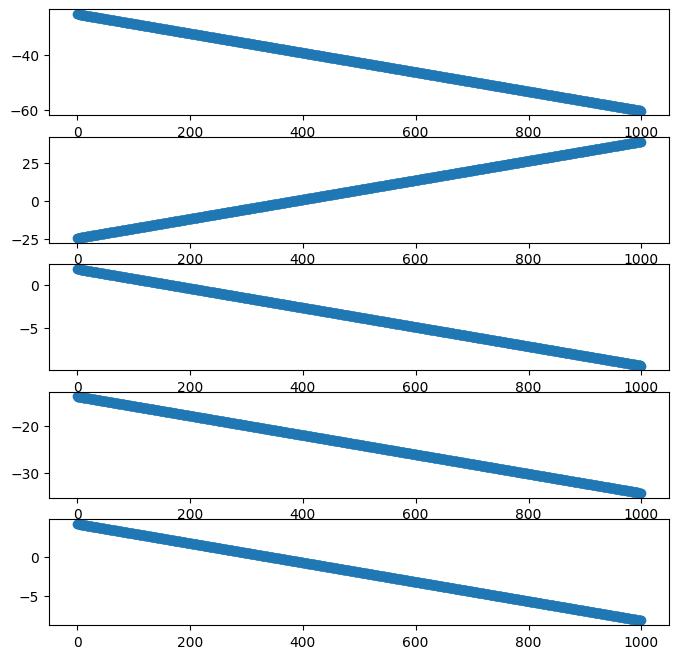

In [41]:
j = 15
traj = paths[:,j]

x0 = traj[:-1]
x1 = traj[1:]
diff = x1 - x0

r = 5
fig, axs = plt.subplots(r, figsize = (8,8))
for i in range(r):
    axs[i].scatter(np.arange(traj.shape[0]), traj[:,i])
plt.show()

In [42]:
#VALIDATE: look at UMAP of distance embeddings

In [43]:
X = adata.obsm['X_pca']
X = torch.from_numpy(X)
X = X.to(embed_model.get_device())
adata.obsm['f_X'] = embed_model.embed_net(X).detach().cpu().numpy()

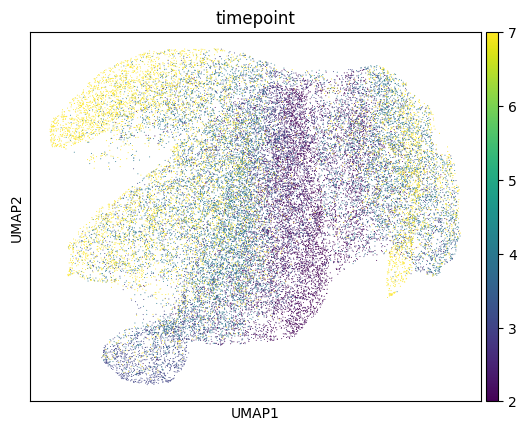

In [44]:
sc.pp.neighbors(adata, use_rep='f_X')
sc.tl.umap(adata)
sc.pl.umap(
    adata,
    color="timepoint",
    # Setting a smaller point size to get prevent overlap
    size=2,
)

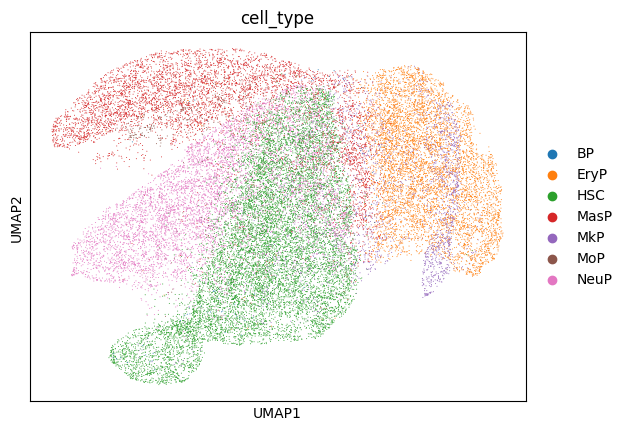

In [45]:
sc.pl.umap(
    adata,
    color="cell_type",
    # Setting a smaller point size to get prevent overlap
    size=2,
)

In [46]:
# #HISTOGRAM of energy based on sampling distance from data
# X = adata.obsm['X_pca']
# X = torch.from_numpy(X)
# sigmas = [0.0, 1e-2, 1e-1, 1e0, 1e1]
# fig, axs = plt.subplots(len(sigmas), figsize=(8,8))
# for i, sigma in enumerate(sigmas):
#     Z = X + sigma * torch.randn_like(X)
#     Z = Z.to(energy_model.get_device())
#     E = energy_model.get_energy(Z).detach().cpu().numpy()
#     axs[i].hist(E)
# plt.show()